# **Исследование объявлений о продаже квартир**
Для исследования взяты данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. 

**Описание датасета:**

`airports_nearest` — расстояние до ближайшего аэропорта в метрах (м)

`balcony` — число балконов

`ceiling_height` — высота потолков (м)

`cityCenters_nearest` — расстояние до центра города (м)

`days_exposition` — сколько дней было размещено объявление (от публикации до снятия)

`first_day_exposition` — дата публикации

`floor` — этаж

`floors_total` — всего этажей в доме

`is_apartment` — апартаменты (булев тип)

`kitchen_area` — площадь кухни в квадратных метрах (м²)

`last_price` — цена на момент снятия с публикации

`living_area` — жилая площадь в квадратных метрах (м²)

`locality_name` — название населённого пункта

`open_plan` — свободная планировка (булев тип)

`parks_around3000` — число парков в радиусе 3 км

`parks_nearest` — расстояние до ближайшего парка (м)

`ponds_around3000` — число водоёмов в радиусе 3 км

`ponds_nearest` — расстояние до ближайшего водоёма (м)

`rooms` — число комнат

`studio` — квартира-студия (булев тип)

`total_area` — общая площадь квартиры в квадратных метрах (м²)

`total_images` — число фотографий квартиры в объявлении


## **Цель:** Изучить данные, сделать выводы о цене недвижимости и о ее продажах

In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('real_estate_data.csv', sep='\t') 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

In [4]:
df.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


## **Анализ пропущенных значений**

In [5]:
df.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

 `balcony`: можно логически предположить, что отстутсвие данных намекает на отстутсвие балкона в квартире впринципе

In [6]:
df['balcony'] = df['balcony'].fillna(0)
df['balcony'].isna().sum()

0

 `is_apartment`: столбец показывает, является ли квартира апартаментми. Логически можно понять, что пропуск является значением 0, то есть квартира не является апартаментом и этот атрибут просто пропустили. Изменим значения на 0:

In [7]:
df['is_apartment'] = df['is_apartment'].fillna('0') 
df['is_apartment'].isna().sum()

0

## **Исправим типы данных в столбцах**

Посмотрим сначала на типы данных, которые у нас есть в таблице:

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          23699 non-null  object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               23699 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

Исправим следующие столбцы: `floors_total`, `balcony`, `days_exposition`. 

In [9]:
floats = ['floors_total','balcony','days_exposition']
for float64 in floats:
    df[float64] = df[float64].astype('int64', errors='ignore')

Теперь исправим `is_apartment`:

In [10]:
df['is_apartment'] = df['is_apartment'].astype('bool',errors='raise')

И дату:

In [11]:
df['first_day_exposition'] = pd.to_datetime(df['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')
df['first_day_exposition']

0       2019-03-07
1       2018-12-04
2       2015-08-20
3       2015-07-24
4       2018-06-19
           ...    
23694   2017-03-21
23695   2018-01-15
23696   2018-02-11
23697   2017-03-28
23698   2017-07-21
Name: first_day_exposition, Length: 23699, dtype: datetime64[ns]

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  float64       
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        14504 non-null  float64       
 6   floors_total          23613 non-null  float64       
 7   living_area           21796 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          23699 non-null  bool          
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          21421 non-null  float64       
 13  balcony         

## **Проверим дубликаты**

In [13]:
df.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.0,8,True,...,25.0,0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04,1,NaN,11.0,18.6,1,True,...,11.0,2,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20,2,NaN,5.0,34.3,4,True,...,8.3,0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24,3,NaN,14.0,NaN,9,True,...,NaN,0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.0,13,True,...,41.0,0,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


In [14]:
#явные дубликаты
print(f"Всего строк: {len(df)}")
print(f"Уникальных строк: {len(df.drop_duplicates())}")
print(f"Дубликатов: {len(df) - len(df.drop_duplicates())}")


Всего строк: 23699
Уникальных строк: 23699
Дубликатов: 0


Неявные дубликаты могут быть, например, в столбце `locality_name`:

In [15]:
df['locality_name'].unique()[:20]

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино'], dtype=object)

In [16]:
df[df['locality_name'].str.contains('посёлок|поселок', na=False, regex=True)]['locality_name'].unique()[:40]

array(['посёлок Шушары', 'городской посёлок Янино-1', 'посёлок Парголово',
       'посёлок Мурино', 'поселок городского типа Красный Бор',
       'поселок Мурино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'поселок Торковичи', 'поселок Первомайское', 'посёлок Понтонный',
       'посёлок Новый Свет', 'поселок Новый Свет', 'поселок Романовка',
       'посёлок Бугры', 'поселок Бугры', 'поселок городского типа Рощино',
       'поселок Оредеж', 'посёлок городского типа Красный Бор',
       'посёлок Молодёжное', 'посёлок Победа',
       'поселок городского типа Синявино',
       'посёлок городского типа Кузьмоловский', 'посёлок Стрельна',
       'посёлок Александровская', 'поселок Терволово',
       'поселок городского типа Советский', 'посёлок Петровское',
       'пос

In [17]:
df['locality_name'] = (df['locality_name'].str.replace('ё', 'е').str.replace('поселок городского типа','поселок').str.replace('городской поселок', 'поселок').str.replace('коттеджный поселок', 'поселок')
)

In [18]:
df['locality_name'].str.split().str[0].unique()

array(['Санкт-Петербург', 'поселок', 'Ломоносов', 'Сертолово', 'Петергоф',
       'Пушкин', 'деревня', 'Коммунар', 'Колпино', 'Гатчина', 'Выборг',
       'Кронштадт', 'Кировск', 'садовое', 'Павловск', 'Всеволожск',
       'Волхов', 'Кингисепп', 'Приозерск', 'Сестрорецк', 'Красное',
       'Сясьстрой', 'Сланцы', 'село', 'Ивангород', 'Мурино',
       'Шлиссельбург', 'Никольское', 'Зеленогорск', 'Сосновый', 'Кудрово',
       'Кириши', 'Луга', 'Волосово', 'Отрадное', 'Тихвин', 'Тосно',
       'Бокситогорск', 'Пикалево', 'Подпорожье', nan, 'Приморск', 'Новая',
       'Лодейное', 'Светогорск', 'Любань', 'Каменногорск',
       'садоводческое', 'Высоцк'], dtype=object)

**Неявные дубликаты устранены**

## **Исправим аномальные значения**

In [19]:
df.describe().loc[['min', 'max']]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
min,0.0,12190.0,12.0,2014-11-27 00:00:00,0.0,1.0,1.0,2.0,1.0,1.3,0.0,0.0,181.0,0.0,1.0,0.0,13.0,1.0
max,50.0,763000000.0,900.0,2019-05-03 00:00:00,19.0,100.0,60.0,409.7,33.0,112.0,5.0,84869.0,65968.0,3.0,3190.0,3.0,1344.0,1580.0


In [20]:
reasonable_min_price = 500_000  # мин 500 тыс. рублей
df = df[df['last_price'] >= reasonable_min_price].copy()

In [21]:
df[df['total_area'] == 900.0]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
19540,8,420000000.0,900.0,2017-12-06,12,2.8,25.0,409.7,25,True,...,112.0,0,Санкт-Петербург,30706.0,7877.0,0.0,NaN,2.0,318.0,106.0


Среднее: 2.7715274808633885


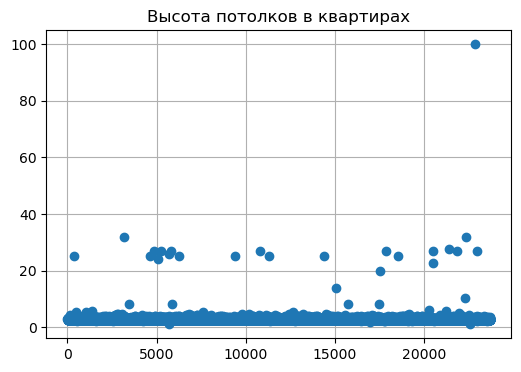

In [22]:
df['ceiling_height'].plot(style='o',grid=True, title='Высота потолков в квартирах', figsize=(6,4));
print(f'Среднее: {df['ceiling_height'].mean()}')

In [23]:
df[df['ceiling_height'] >= 30.0]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
3148,14,2900000.0,75.0,2018-11-12,3,32.0,3.0,53.0,2,True,...,8.0,0,Волхов,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22336,19,9999000.0,92.4,2019-04-05,2,32.0,6.0,55.5,5,False,...,16.5,4,Санкт-Петербург,18838.0,3506.0,0.0,NaN,3.0,511.0,NaN
22869,0,15000000.0,25.0,2018-07-25,1,100.0,5.0,14.0,5,True,...,11.0,5,Санкт-Петербург,34963.0,8283.0,1.0,223.0,3.0,30.0,19.0


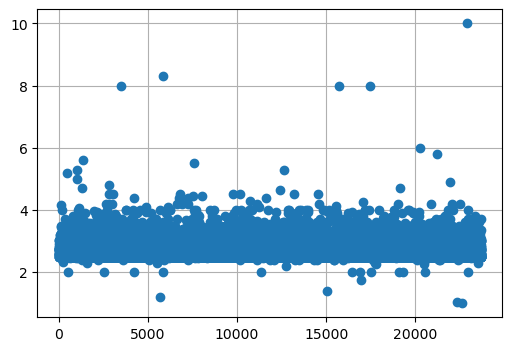

In [24]:
def replace_big(info):
    info = info['ceiling_height']
    if 10 <= info <= 100:
        return info / 10
    else:
        return info

df['ceiling_height'] = df.apply(replace_big, axis=1)
df['ceiling_height'].plot(style='o',grid=True, figsize=(6,4));

## **Добавим в таблицу новые столбцы**

In [25]:
df['price_per_m2'] = df['last_price'] / df['total_area']
df['sale_date'] = df['first_day_exposition'] + pd.to_timedelta(df['days_exposition'], unit='D')
df['sale_year'] = df['sale_date'].dt.year
df['sale_month'] = df['sale_date'].dt.month
df['cityCenters_nearest_kilo'] = (df['cityCenters_nearest']/1000).round(0)

def floor_category(row):
    if pd.isna(row['floors_total']):
        return 'unknown'
    if row['floor'] == 1:
        return 'first'
    elif row['floor'] == row['floors_total']:
        return 'last'
    else:
        return 'other'

df['floor_category'] = df.apply(floor_category, axis=1)
df

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_per_m2,sale_date,sale_year,sale_month,cityCenters_nearest_kilo,floor_category
0,20,13000000.0,108.00,2019-03-07,3,2.70,16.0,51.0,8,True,...,482.0,2.0,755.0,NaN,120370.370370,NaT,NaN,NaN,16.0,other
1,7,3350000.0,40.40,2018-12-04,1,NaN,11.0,18.6,1,True,...,NaN,0.0,NaN,81.0,82920.792079,2019-02-23,2019.0,2.0,19.0,first
2,10,5196000.0,56.00,2015-08-20,2,NaN,5.0,34.3,4,True,...,90.0,2.0,574.0,558.0,92785.714286,2017-02-28,2017.0,2.0,14.0,other
3,0,64900000.0,159.00,2015-07-24,3,NaN,14.0,NaN,9,True,...,84.0,3.0,234.0,424.0,408176.100629,2016-09-20,2016.0,9.0,7.0,other
4,2,10000000.0,100.00,2018-06-19,2,3.03,14.0,32.0,13,True,...,112.0,1.0,48.0,121.0,100000.000000,2018-10-18,2018.0,10.0,8.0,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,9,9700000.0,133.81,2017-03-21,3,3.70,5.0,73.3,3,True,...,796.0,3.0,381.0,NaN,72490.845228,NaT,NaN,NaN,4.0,other
23695,14,3100000.0,59.00,2018-01-15,3,NaN,5.0,38.0,4,True,...,NaN,NaN,NaN,45.0,52542.372881,2018-03-01,2018.0,3.0,NaN,other
23696,18,2500000.0,56.70,2018-02-11,2,NaN,3.0,29.7,1,True,...,NaN,NaN,NaN,NaN,44091.710758,NaT,NaN,NaN,NaN,first
23697,13,11475000.0,76.75,2017-03-28,2,3.00,17.0,NaN,12,True,...,173.0,3.0,196.0,602.0,149511.400651,2018-11-20,2018.0,11.0,10.0,other


# **Исследовательский анализ данных**


In [26]:
df.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_per_m2,sale_date,sale_year,sale_month,cityCenters_nearest_kilo,floor_category
0,20,13000000.0,108.00,2019-03-07,3,2.70,16.0,51.00,8,True,...,482.0,2.0,755.0,NaN,120370.370370,NaT,NaN,NaN,16.0,other
1,7,3350000.0,40.40,2018-12-04,1,NaN,11.0,18.60,1,True,...,NaN,0.0,NaN,81.0,82920.792079,2019-02-23,2019.0,2.0,19.0,first
2,10,5196000.0,56.00,2015-08-20,2,NaN,5.0,34.30,4,True,...,90.0,2.0,574.0,558.0,92785.714286,2017-02-28,2017.0,2.0,14.0,other
3,0,64900000.0,159.00,2015-07-24,3,NaN,14.0,NaN,9,True,...,84.0,3.0,234.0,424.0,408176.100629,2016-09-20,2016.0,9.0,7.0,other
4,2,10000000.0,100.00,2018-06-19,2,3.03,14.0,32.00,13,True,...,112.0,1.0,48.0,121.0,100000.000000,2018-10-18,2018.0,10.0,8.0,other
5,10,2890000.0,30.40,2018-09-10,1,NaN,12.0,14.40,5,True,...,NaN,NaN,NaN,55.0,95065.789474,2018-11-04,2018.0,11.0,NaN,other
6,6,3700000.0,37.30,2017-11-02,1,NaN,26.0,10.60,6,True,...,NaN,0.0,NaN,155.0,99195.710456,2018-04-06,2018.0,4.0,19.0,other
7,5,7915000.0,71.60,2019-04-18,2,NaN,24.0,NaN,22,True,...,NaN,0.0,NaN,NaN,110544.692737,NaT,NaN,NaN,12.0,other
8,20,2900000.0,33.16,2018-05-23,1,NaN,27.0,15.43,26,True,...,NaN,NaN,NaN,189.0,87454.764777,2018-11-28,2018.0,11.0,NaN,other
9,18,5400000.0,61.00,2017-02-26,3,2.50,9.0,43.60,7,True,...,NaN,0.0,NaN,289.0,88524.590164,2017-12-12,2017.0,12.0,15.0,other


## **Посмотрим на активность объявлений**


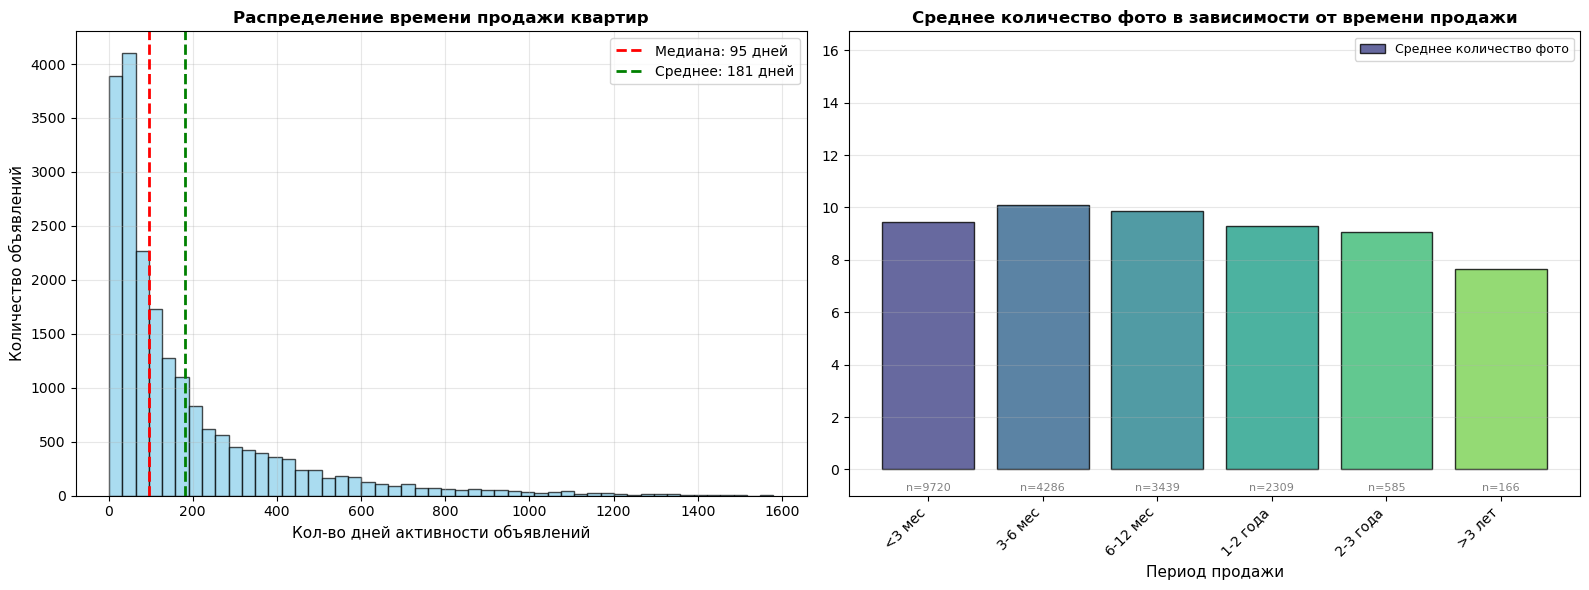

In [27]:
# Создаем фигуру с двумя subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df_clean = df.dropna(subset = ['days_exposition'])
# Левый график: гистограмма дней продажи
ax1 = axes[0]
df_clean['days_exposition'].hist(bins=50, ax=ax1, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Кол-во дней активности объявлений', fontsize=11)
ax1.set_ylabel('Количество объявлений', fontsize=11)
ax1.set_title('Распределение времени продажи квартир', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Добавляем вертикальные линии для медианы и среднего
median_days = df_clean['days_exposition'].median()
mean_days = df_clean['days_exposition'].mean()

ax1.axvline(median_days, color='red', linestyle='--', linewidth=2, 
           label=f'Медиана: {median_days:.0f} дней')
ax1.axvline(mean_days, color='green', linestyle='--', linewidth=2,
           label=f'Среднее: {mean_days:.0f} дней')
ax1.legend(fontsize=10)

# Правый график: СРЕДНЕЕ количество фото в зависимости от периода продажи
ax2 = axes[1]

# Создаем категории периодов продажи
period_bins = [0, 90, 180, 365, 730, 1095, df_clean['days_exposition'].max()]
period_labels = ['<3 мес', '3-6 мес', '6-12 мес', '1-2 года', '2-3 года', '>3 лет']

df_clean['sales_period'] = pd.cut(df['days_exposition'], 
                           bins=period_bins, 
                           labels=period_labels, 
                           include_lowest=True)

# Группируем по периодам и считаем СРЕДНЕЕ количество фото
if 'total_images' in df_clean.columns:
    # Агрегируем: среднее, медиана, количество объявлений
    photos_by_period = df_clean.groupby('sales_period')['total_images'].agg(['mean', 'median', 'count', 'std']).round(2)
    
    # Используем СРЕДНЕЕ значение для столбцов
    x_pos = np.arange(len(photos_by_period))
    bars = ax2.bar(x_pos, photos_by_period['mean'], 
                  color=plt.cm.viridis(np.linspace(0.2, 0.8, len(photos_by_period))),
                  edgecolor='black', alpha=0.8, 
                  label='Среднее количество фото')

    ax2.set_xlabel('Период продажи', fontsize=11)
    ax2.set_title('Среднее количество фото в зависимости от времени продажи', 
                 fontsize=12, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(period_labels, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.legend(loc='upper right', fontsize=9)
    
    # Добавляем значения на столбцы (среднее значение)
    for i, (bar, mean_val, median_val, count_val) in enumerate(zip(bars, 
                                                              photos_by_period['mean'], 
                                                              photos_by_period['median'],
                                                              photos_by_period['count'])):
        height = bar.get_height()
        
        # Количество объявлений внизу
        ax2.text(bar.get_x() + bar.get_width()/2, -0.5, 
                f'n={int(count_val)}', 
                ha='center', va='top', fontsize=8, color='gray')
    
    # Настраиваем пределы оси Y, чтобы вместить все подписи
    y_max = max(photos_by_period['mean'] + photos_by_period['std']) + 1
    ax2.set_ylim(bottom=-1, top=y_max)
plt.tight_layout()



**Вывод**: Среднее время продажи - 3-6 месяцев. И это достаточно быстрые продажи, но встречаются и большие значения - некоторые квартиры продавались больше 4-х лет.

## **Исследуем цены на недвижимость**


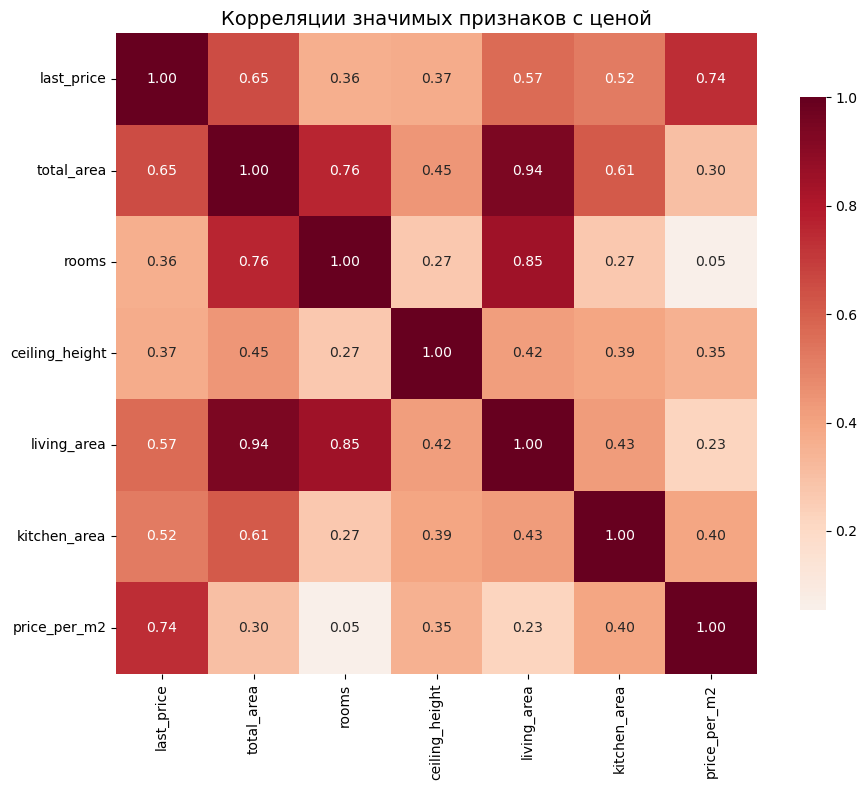

In [28]:
# Отбираем только колонки с высокой корреляцией с ценой
corr_matrix = df.corr(numeric_only=True)
important_cols = corr_matrix['last_price'][abs(corr_matrix['last_price']) > 0.3].index
corr_filtered = corr_matrix.loc[important_cols, important_cols]

# Рисуем для отфильтрованных
plt.figure(figsize=(10, 8))
sns.heatmap(corr_filtered, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0,
            square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Корреляции значимых признаков с ценой', fontsize=14)
plt.tight_layout()
plt.show()

 Чем больше общая площадь/жил. площадь/площадь кухни, тем больше цена.

In [29]:
fig = px.scatter_3d(df, x='total_area', y='rooms', z='last_price',
                    color='total_area', size_max=1, opacity=0.6)

fig.update_layout(
    height=800, 
    width=1200,
    scene=dict(
        xaxis=dict(range=[0, 200]),  # Ограничиваем total_area
        yaxis=dict(range=[0, 15]),   # Ограничиваем rooms
        zaxis=dict(range=[0, 100_000_000])  # Ограничиваем цену
    )
)
fig.update_traces(marker=dict(size=4, opacity=0.3))
fig.show()

Из графика видно, что с возрастанием площади разброс значений цены на квартиры становится больше, исследуем это подробнее

Посчитаем стандартное отклонение, нормированное на среднюю цену (коэффициент вариации) для каждой группы площадей:
$$CV = \frac{\sigma}{\bar{x}} \times 100\%$$


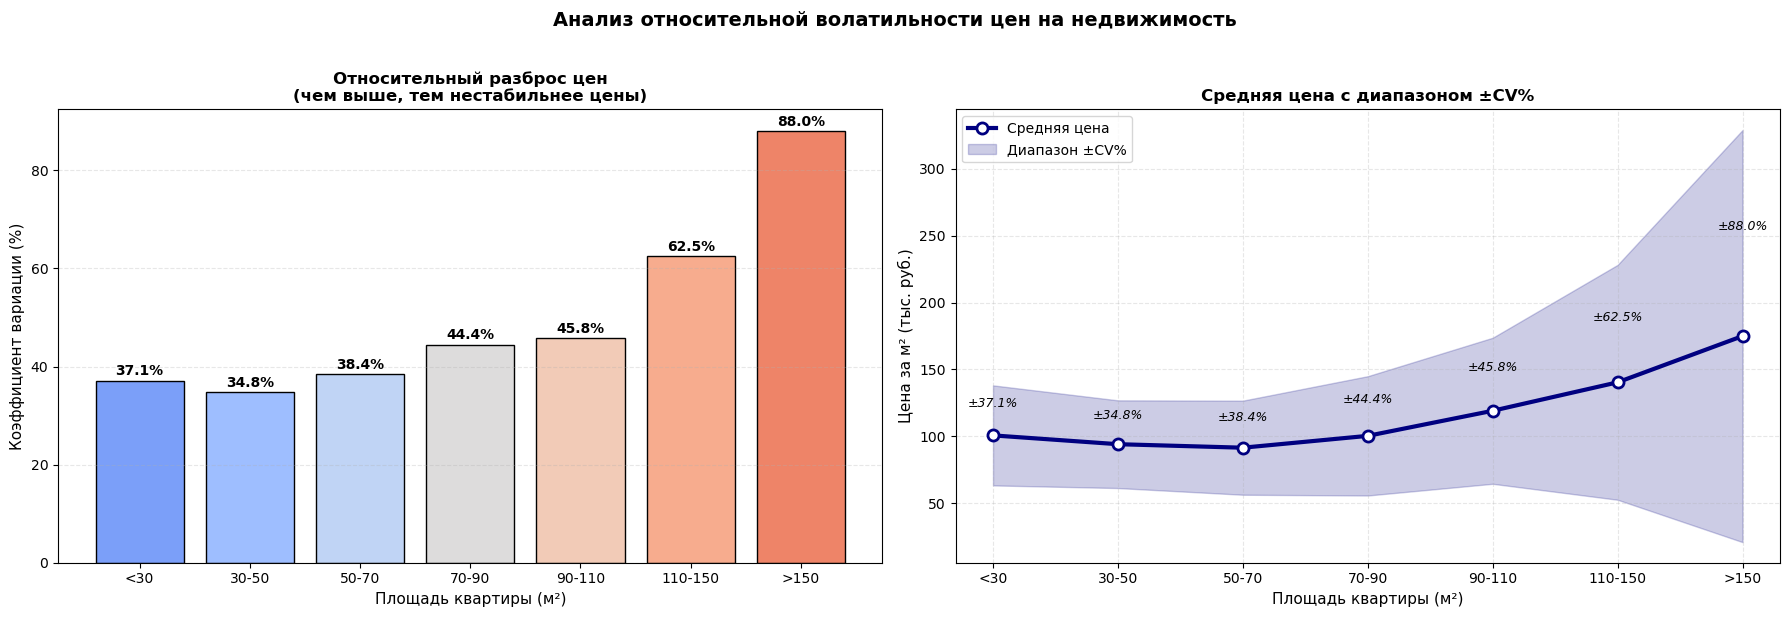

In [30]:
df['area_cohort'] = pd.cut(df['total_area'], 
                           bins=[0, 30, 50, 70, 90, 110, 150, 300],
                           labels=['<30', '30-50', '50-70', '70-90', '90-110', '110-150', '>150'])

cohort_stats = df.groupby('area_cohort')['price_per_m2'].agg(['mean', 'std', 'count']).round(2)
cohort_stats['cv'] = (cohort_stats['std'] / cohort_stats['mean'] * 100).round(1)  # CV в %
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

bars = ax1.bar(cohort_stats.index, cohort_stats['cv'], 
               color=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(cohort_stats))),
               edgecolor='black')
ax1.set_xlabel('Площадь квартиры (м²)', fontsize=11)
ax1.set_ylabel('Коэффициент вариации (%)', fontsize=11)
ax1.set_title('Относительный разброс цен\n(чем выше, тем нестабильнее цены)', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

for bar, cv in zip(bars, cohort_stats['cv']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, 
             f'{cv}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
mean_prices = cohort_stats['mean'] / 1000 
lower_bound = mean_prices * (1 - cohort_stats['cv']/100)
upper_bound = mean_prices * (1 + cohort_stats['cv']/100)

ax2.plot(cohort_stats.index, mean_prices, 'o-', 
         linewidth=3, markersize=8, color='navy', 
         markerfacecolor='white', markeredgewidth=2, label='Средняя цена')
ax2.fill_between(cohort_stats.index, lower_bound, upper_bound,
                 alpha=0.2, color='navy', label=f'Диапазон ±CV%')

ax2.set_xlabel('Площадь квартиры (м²)', fontsize=11)
ax2.set_ylabel('Цена за м² (тыс. руб.)', fontsize=11)
ax2.set_title('Средняя цена с диапазоном ±CV%', fontsize=12, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(alpha=0.3, linestyle='--')
for i, (mean_val, cv_val) in enumerate(zip(mean_prices, cohort_stats['cv'])):
    ax2.text(i, mean_val + (mean_val * cv_val/100)/2, 
             f'±{cv_val}%', ha='center', va='bottom', fontsize=9, style='italic')

plt.suptitle('Анализ относительной волатильности цен на недвижимость', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Как правило, если коэф-т вариации < 33%, совокупность считается однородной.**

В нашем случае в каждой группе коэф-т вариации превышает 33%, следовательно, для любой площади значения цены имеют достаточно большой разброс, и среднее арифметическое не будет отражать ситуацию в полной мере. Вместо него лучше использовать медианное значение и исключать аномально большие значения.

Также видно, что с увеличением площади этот разброс становится все больше.

**Вывод:** Чем больше общая площадь, тем больше разброс значений цены за квадратный метр.
Количество комнат в квартирах влияет на цену не так сильно, как общая площадь

## **Как сильно влияет этаж на цену?**

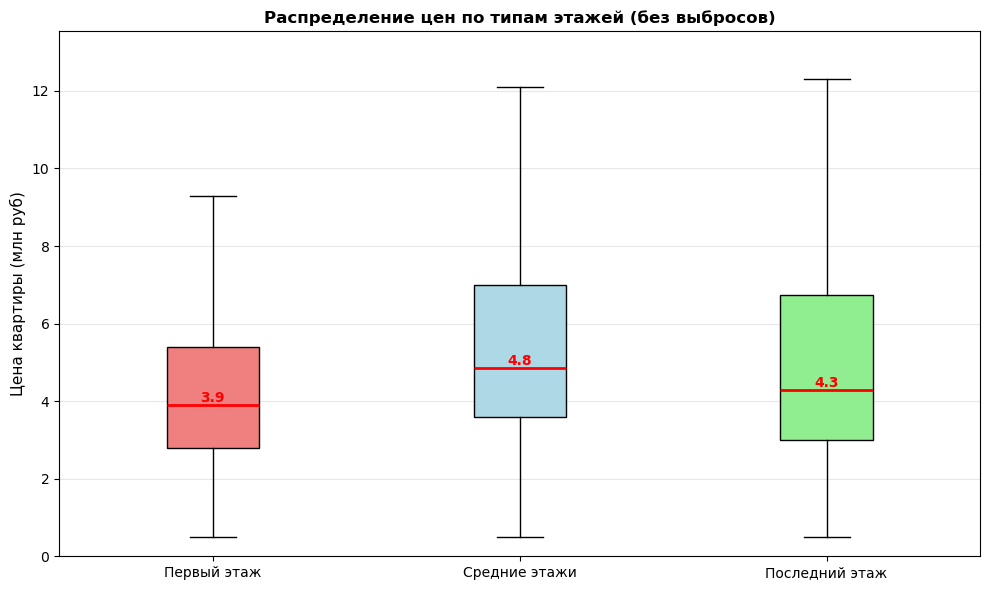

,count,mean,std,min,25%,50%,75%,max
floor_category,,,,,,,,
first,2909.0,4.813186e+06,5.102154e+06,500000.0,2800000.0,3900000.0,5400000.0,135000000.0
last,3331.0,7.371512e+06,2.070672e+07,500000.0,3000000.0,4300000.0,6725000.0,763000000.0
other,17359.0,6.675505e+06,8.623791e+06,500000.0,3600000.0,4850000.0,7000000.0,330000000.0
unknown,86.0,6.814282e+06,5.551092e+06,1640000.0,3480000.0,5192500.0,7523265.0,40348248.0


In [31]:
floor_counts = df['floor_category'].value_counts()
price_stats_by_floor = df.groupby('floor_category')['last_price'].describe(percentiles=[.25, .5, .75])

fig, ax = plt.subplots(figsize=(10, 6))
box_data = [
    df[df['floor_category'] == 'first']['last_price'] / 1e6,
    df[df['floor_category'] == 'other']['last_price'] / 1e6,
    df[df['floor_category'] == 'last']['last_price'] / 1e6
]

# Создаем боксплот
box = ax.boxplot(box_data, 
                 labels=['Первый этаж', 'Средние этажи', 'Последний этаж'],
                 patch_artist=True,
                 showfliers=False)  # Без выбросов

# Раскрашиваем боксы
colors = ['lightcoral', 'lightblue', 'lightgreen']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Добавляем точки для медиан
for i, median_line in enumerate(box['medians']):
    median_line.set_color('red')
    median_line.set_linewidth(2)
    
    median_value = price_stats_by_floor.loc[['first', 'other', 'last'][i], '50%'] / 1e6
    ax.text(i+1, median_value, f'{median_value:.1f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=10, color='red')

# Настройки графика
ax.set_ylabel('Цена квартиры (млн руб)', fontsize=11)
ax.set_title('Распределение цен по типам этажей (без выбросов)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# САМОЕ ВАЖНОЕ: Правильно вычисляем верхний предел
# Находим максимальное значение "усов" для каждого бокса
upper_whiskers = []
for data in box_data:
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    upper_whisker = q3 + 1.5 * iqr
    # Но не больше максимума данных (так как showfliers=False)
    upper_whisker = min(upper_whisker, data.max())
    upper_whiskers.append(upper_whisker)

# Устанавливаем пределы с запасом 10%
ax.set_ylim(bottom=0, top=max(upper_whiskers) * 1.1)

plt.tight_layout()
plt.show()
price_stats_by_floor

1. Цены не распределены нормально, есть тяжелый правый хвост

2. Есть много дорогих квартир относительно медианной цены

3. Рынок неоднороден - в одной категории этажей могут быть и дешевые, и очень дорогие квартиры, в особенности для последних этажей

4. На первых этажах квартиры дешевле, чем на остальных, и разброс значений меньше

## **Квартиры в сравнении с Апартаментами**

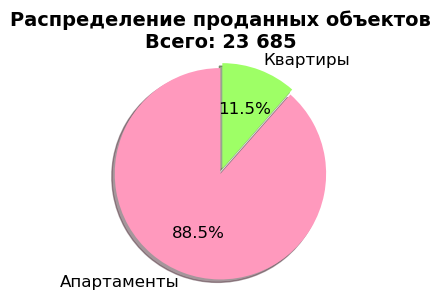

,flat,apartment
Количество проданных,2 725,20 960
Средняя цена (руб.),6 522 225,6 548 145
Медианная цена (руб.),4 700 000,4 622 500
Цена за м² (руб.),98 528,99 597


In [32]:
apart_mean_price = df[df['is_apartment']]['last_price'].mean()
apart_mediam_price = df[df['is_apartment']]['last_price'].median()
apart_mean_m2_price = df[df['is_apartment']]['price_per_m2'].mean()
apart_sold_count = df[df['is_apartment']]['last_price'].count()

flat_mean_price = df[df['is_apartment']==False]['last_price'].mean()
flat_mediam_price = df[df['is_apartment']==False]['last_price'].median()
flat_mean_m2_price = df[df['is_apartment']==False]['price_per_m2'].mean()
flat_sold_count = df[~df['is_apartment']]['last_price'].count()

compare_df = pd.DataFrame({
    'flat': [
        f"{flat_sold_count:,}".replace(',', ' '),
        f"{flat_mean_price:,.0f}".replace(',', ' '),
        f"{flat_mediam_price:,.0f}".replace(',', ' '),
        f"{flat_mean_m2_price:,.0f}".replace(',', ' ')
    ],
    'apartment': [
        f"{apart_sold_count:,}".replace(',', ' '),
        f"{apart_mean_price:,.0f}".replace(',', ' '),
        f"{apart_mediam_price:,.0f}".replace(',', ' '),
        f"{apart_mean_m2_price:,.0f}".replace(',', ' ')
    ]
}, index=['Количество проданных', 'Средняя цена (руб.)', 'Медианная цена (руб.)', 'Цена за м² (руб.)'])
# 1. Круговая диаграмма (доля на рынке)
labels = ['Апартаменты', 'Квартиры']
sizes = [apart_sold_count, flat_sold_count]
colors = ["#ff99bd", "#9eff66"] 
explode = (0.05, 0)  # Выделяем апартаменты

plt.figure(figsize=(3, 3))
plt.pie(sizes, labels=labels, colors=colors, explode=explode,
        autopct='%1.1f%%', startangle=90, shadow=True,
        textprops={'fontsize': 12})
plt.axis('equal')
plt.title(f'Распределение проданных объектов\nВсего: {sum(sizes):,}'.replace(',', ' '), 
          fontsize=14, fontweight='bold')
plt.show()
plt.show()
compare_df

В нашем случае апартаменты не отличаются от квартир по цене.
Однако апартаментов продано намного больше.

## **Периоды продаж**

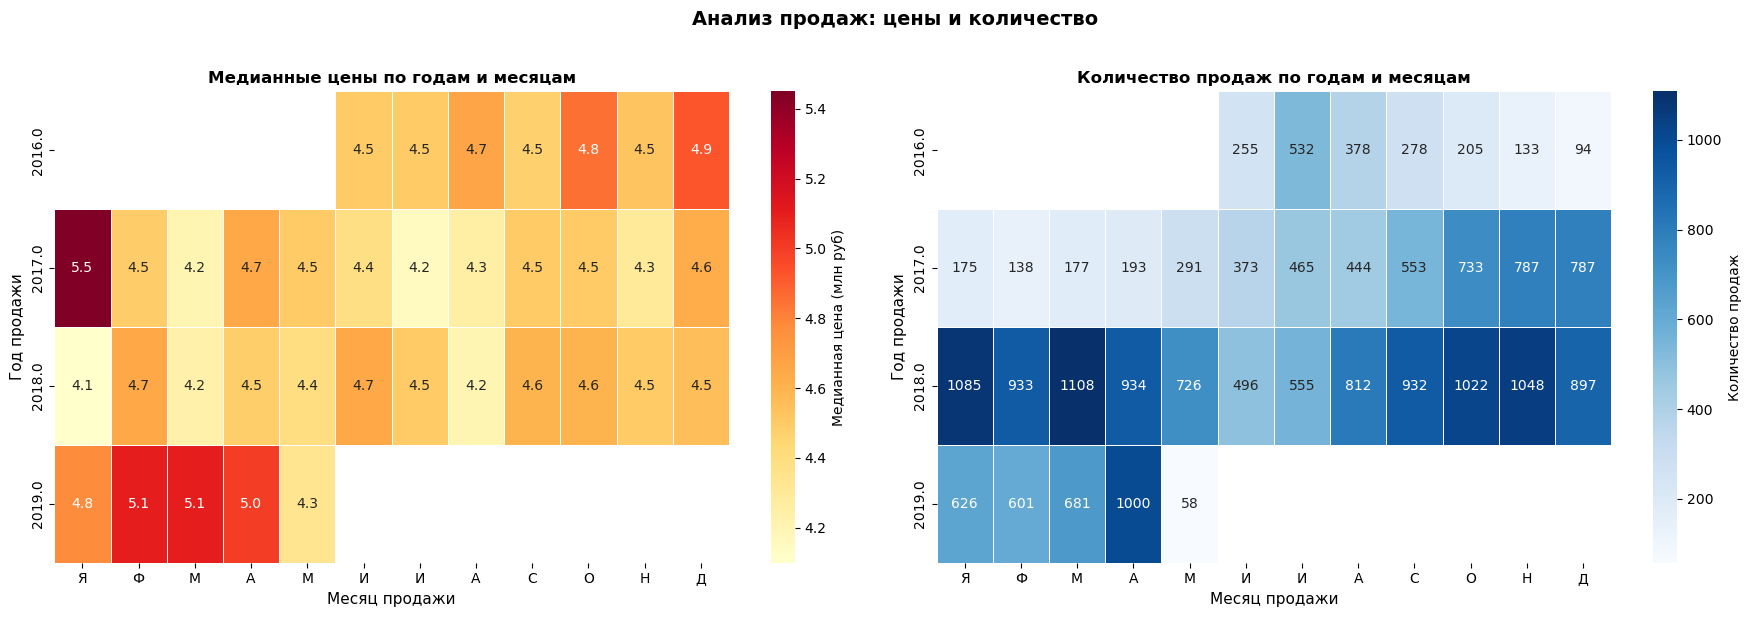


Распределение продаж по месяцам:
  Янв: 1886 продаж (9.2%)
  Фев: 1672 продаж (8.2%)
  Мар: 1966 продаж (9.6%)
  Апр: 2127 продаж (10.4%)
  Май: 1075 продаж (5.2%)
  Июн: 1124 продаж (5.5%)
  Июл: 1552 продаж (7.6%)
  Авг: 1634 продаж (8.0%)
  Сен: 1763 продаж (8.6%)
  Окт: 1960 продаж (9.6%)
  Ноя: 1968 продаж (9.6%)
  Дек: 1778 продаж (8.7%)


In [33]:
df_clean = df.dropna(subset=['sale_year', 'sale_month', 'last_price']).copy()

price_table = df_clean.pivot_table(
    index='sale_year',
    columns='sale_month', 
    values='last_price',
    aggfunc='median'
) / 1e6

count_table = df_clean.pivot_table(
    index='sale_year',
    columns='sale_month',
    values='last_price',
    aggfunc='count'
)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(
    price_table, 
    cmap='YlOrRd', 
    annot=True, 
    fmt='.1f',
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={'label': 'Медианная цена (млн руб)'}
)
axes[0].set_xlabel('Месяц продажи', fontsize=11)
axes[0].set_ylabel('Год продажи', fontsize=11)
axes[0].set_title('Медианные цены по годам и месяцам', fontsize=12, fontweight='bold')
sns.heatmap(
    count_table, 
    cmap='Blues', 
    annot=True, 
    fmt='.0f',
    linewidths=0.5,
    ax=axes[1],
    cbar_kws={'label': 'Количество продаж'}
)
axes[1].set_xlabel('Месяц продажи', fontsize=11)
axes[1].set_ylabel('Год продажи', fontsize=11)
axes[1].set_title('Количество продаж по годам и месяцам', fontsize=12, fontweight='bold')

# Подписи месяцев для обоих графиков
months_short = ['Я', 'Ф', 'М', 'А', 'М', 'И', 'И', 'А', 'С', 'О', 'Н', 'Д']
for ax in axes:
    ax.set_xticks(np.arange(12) + 0.5)
    ax.set_xticklabels(months_short, rotation=0)

plt.suptitle('Анализ продаж: цены и количество', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
monthly_counts = df_clean['sale_month'].value_counts().sort_index()

print("\nРаспределение продаж по месяцам:")
for month, count in enumerate(monthly_counts.values, 1):
    percent = (count / monthly_counts.sum()) * 100
    month_name = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
                  'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'][month-1]
    print(f"  {month_name}: {count} продаж ({percent:.1f}%)")

## **Топ-10 населенных пунктов**

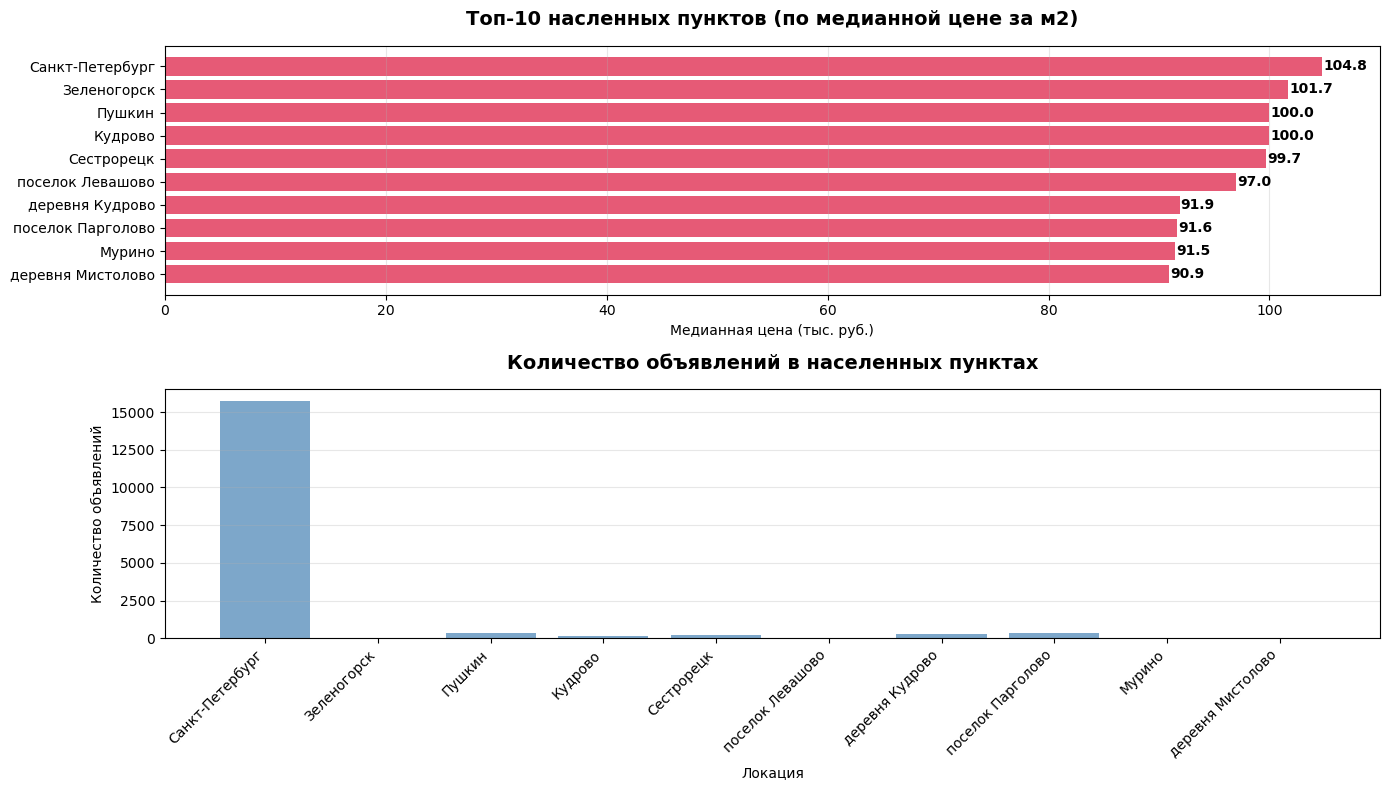

In [34]:
top_10_expensive = df.groupby('locality_name')['price_per_m2'].agg(['median', 'count']).sort_values('median', ascending=False).head(10)
plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
bars = plt.barh(top_10_expensive.index, top_10_expensive['median'] /1_000, 
                color='crimson', alpha=0.7)
plt.xlabel('Медианная цена (тыс. руб.)')
plt.title('Топ-10 насленных пунктов (по медианной цене за м2)', fontsize=14, fontweight='bold', pad=15)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}', va='center', fontsize=10, fontweight='bold')

plt.gca().invert_yaxis() 
plt.grid(True, alpha=0.3, axis='x')
plt.subplot(2, 1, 2)
plt.bar(top_10_expensive.index, top_10_expensive['count'], 
        color='steelblue', alpha=0.7)
plt.xlabel('Локация')
plt.ylabel('Количество объявлений')
plt.title('Количество объявлений в населенных пунктах', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## **СПБ**

In [35]:
spb = df.loc[df['locality_name'] == "Санкт-Петербург"]
spb

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_around3000,ponds_nearest,days_exposition,price_per_m2,sale_date,sale_year,sale_month,cityCenters_nearest_kilo,floor_category,area_cohort
0,20,13000000.0,108.00,2019-03-07,3,2.70,16.0,51.0,8,True,...,2.0,755.0,NaN,120370.370370,NaT,NaN,NaN,16.0,other,90-110
2,10,5196000.0,56.00,2015-08-20,2,NaN,5.0,34.3,4,True,...,2.0,574.0,558.0,92785.714286,2017-02-28,2017.0,2.0,14.0,other,50-70
3,0,64900000.0,159.00,2015-07-24,3,NaN,14.0,NaN,9,True,...,3.0,234.0,424.0,408176.100629,2016-09-20,2016.0,9.0,7.0,other,>150
4,2,10000000.0,100.00,2018-06-19,2,3.03,14.0,32.0,13,True,...,1.0,48.0,121.0,100000.000000,2018-10-18,2018.0,10.0,8.0,other,90-110
7,5,7915000.0,71.60,2019-04-18,2,NaN,24.0,NaN,22,True,...,0.0,NaN,NaN,110544.692737,NaT,NaN,NaN,12.0,other,70-90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23689,13,3550000.0,35.30,2018-02-28,1,2.86,15.0,16.3,4,True,...,2.0,652.0,29.0,100566.572238,2018-03-29,2018.0,3.0,16.0,other,30-50
23690,3,5500000.0,52.00,2018-07-19,2,NaN,5.0,31.0,2,True,...,0.0,NaN,15.0,105769.230769,2018-08-03,2018.0,8.0,6.0,other,50-70
23691,11,9470000.0,72.90,2016-10-13,2,2.75,25.0,40.3,7,True,...,1.0,806.0,519.0,129903.978052,2018-03-16,2018.0,3.0,4.0,other,70-90
23694,9,9700000.0,133.81,2017-03-21,3,3.70,5.0,73.3,3,True,...,3.0,381.0,NaN,72490.845228,NaT,NaN,NaN,4.0,other,110-150


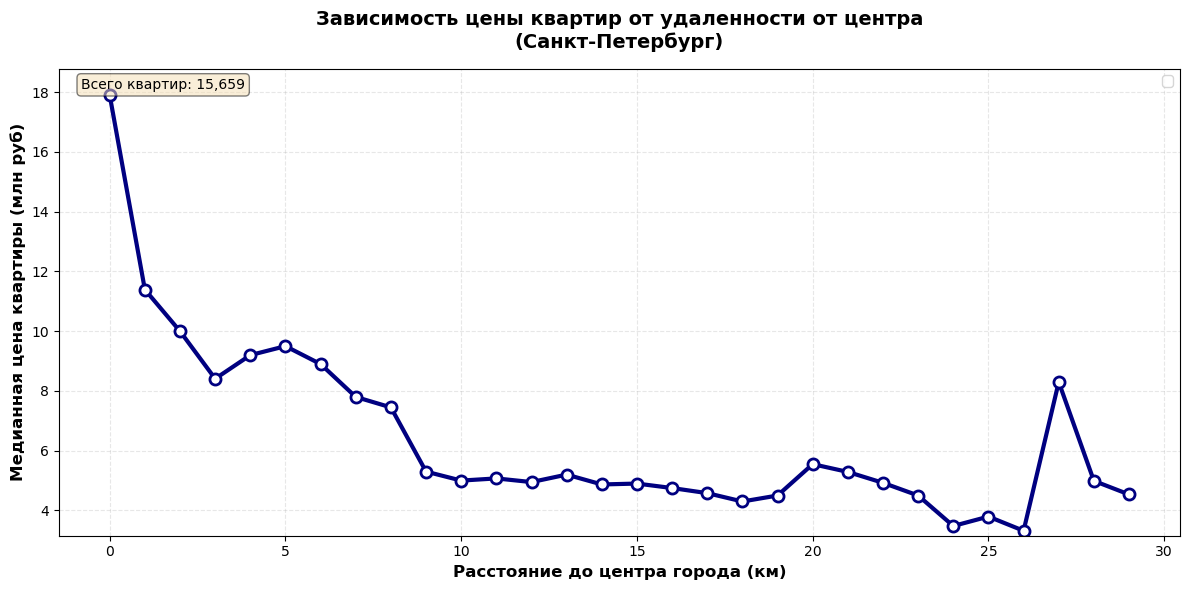

In [36]:
# Создаем pivot table
spb_kilo = spb.pivot_table(index='cityCenters_nearest_kilo', values='last_price', aggfunc='median')
spb_kilo = spb_kilo.round(0)
fig, ax = plt.subplots(figsize=(12, 6))
line = ax.plot(spb_kilo.index, spb_kilo['last_price'] / 1e6, 
               'o-', linewidth=3, markersize=8, 
               color='navy', markerfacecolor='white', markeredgewidth=2)
# Настройки осей
ax.set_xlabel('Расстояние до центра города (км)', fontsize=12, fontweight='bold')
ax.set_ylabel('Медианная цена квартиры (млн руб)', fontsize=12, fontweight='bold')
ax.set_title('Зависимость цены квартир от удаленности от центра\n(Санкт-Петербург)', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--')
if len(spb_kilo) > 2:
    ax.legend(loc='best', fontsize=10)
y_min = (spb_kilo['last_price'].min() / 1e6) * 0.95
y_max = (spb_kilo['last_price'].max() / 1e6) * 1.05
ax.set_ylim(y_min, y_max)
total_count = spb.groupby('cityCenters_nearest_kilo').size().sum()
ax.text(0.02, 0.98, f'Всего квартир: {total_count:,}', 
        transform=ax.transAxes, fontsize=10, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

**Вывод**: Чем дальше от центра - тем меньше стоит квартира.

## **Парки и водоемы**

In [37]:
spb.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_around3000,ponds_nearest,days_exposition,price_per_m2,sale_date,sale_year,sale_month,cityCenters_nearest_kilo,floor_category,area_cohort
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.0,8,True,...,2.0,755.0,NaN,120370.370370,NaT,NaN,NaN,16.0,other,90-110
2,10,5196000.0,56.0,2015-08-20,2,NaN,5.0,34.3,4,True,...,2.0,574.0,558.0,92785.714286,2017-02-28,2017.0,2.0,14.0,other,50-70
3,0,64900000.0,159.0,2015-07-24,3,NaN,14.0,NaN,9,True,...,3.0,234.0,424.0,408176.100629,2016-09-20,2016.0,9.0,7.0,other,>150
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.0,13,True,...,1.0,48.0,121.0,100000.000000,2018-10-18,2018.0,10.0,8.0,other,90-110
7,5,7915000.0,71.6,2019-04-18,2,NaN,24.0,NaN,22,True,...,0.0,NaN,NaN,110544.692737,NaT,NaN,NaN,12.0,other,70-90
9,18,5400000.0,61.0,2017-02-26,3,2.50,9.0,43.6,7,True,...,0.0,NaN,289.0,88524.590164,2017-12-12,2017.0,12.0,15.0,other,50-70
10,5,5050000.0,39.6,2017-11-16,1,2.67,12.0,20.3,3,True,...,2.0,553.0,137.0,127525.252525,2018-04-02,2018.0,4.0,14.0,other,30-50
15,16,4650000.0,39.0,2017-11-18,1,NaN,14.0,20.5,5,True,...,1.0,296.0,19.0,119230.769231,2017-12-07,2017.0,12.0,14.0,other,30-50
16,11,6700000.0,82.0,2017-11-23,3,3.05,5.0,55.6,1,True,...,0.0,NaN,397.0,81707.317073,2018-12-25,2018.0,12.0,11.0,first,70-90
17,6,4180000.0,36.0,2016-09-09,1,NaN,17.0,16.5,7,True,...,1.0,859.0,571.0,116111.111111,2018-04-03,2018.0,4.0,15.0,other,30-50


Информация о парках и водоемах:

In [38]:
park_columns = ['parks_nearest', 'parks_around3000']
pond_columns = ['ponds_nearest', 'ponds_around3000']

for col_list, name in [(park_columns, "парки"), (pond_columns, "водоемы")]:
    available_cols = [col for col in col_list if col in spb.columns]
    missing_cols = [col for col in col_list if col not in spb.columns]
    
    if available_cols:
        print(f"{name}: {', '.join(available_cols)}")
        for col in available_cols:
            non_null = spb[col].notna().sum()
            total = len(spb)
            print(f"  {col}: {non_null}/{total} записей ({non_null/total*100:.1f}%)")
            
    if missing_cols:
        print(f"✗ Отсутствуют данные: {', '.join(missing_cols)}")

парки: parks_nearest, parks_around3000
  parks_nearest: 7283/15720 записей (46.3%)
  parks_around3000: 15659/15720 записей (99.6%)
водоемы: ponds_nearest, ponds_around3000
  ponds_nearest: 7983/15720 записей (50.8%)
  ponds_around3000: 15659/15720 записей (99.6%)


In [39]:
# Удаляем строки с NaN в колонках парков и водоемов
spb_clean = spb.dropna(subset=['parks_nearest', 'ponds_nearest'])
fig = px.scatter_3d(spb_clean, x='ponds_nearest', y='parks_nearest', z='last_price',
                    color='cityCenters_nearest_kilo', size_max=1, opacity=0.6)

fig.update_layout(
    height=800, 
    width=1200,
    scene=dict(
        xaxis=dict(range=[0, 1500]), 
        yaxis=dict(range=[0, 1500]),   
        zaxis=dict(range=[0, 50_000_000]) 
    )
)
fig.update_traces(marker=dict(size=4, opacity=0.3))
fig.show()
print(f'Не учтено записей: {len(spb) - len(spb_clean)}')

Не учтено записей: 11460


Наивысшую цену имеют квартиры, близкие к центру, паркам и водоемам.

# **Выводы**
1. Среднее время продажи квартир составляет 3-6 месяцев;

2. Наиболее сильно влияют на цену расстояние до центра и общая площадь квартиры;

3. При поиске квартиры опредеденной площади лучше не полагаться на среднюю цену продажи, так как разброс значений может быть очень большим;

4. Для квартир на первом этаже разброс и медианная цена меньше, выбор недвижимости на первом этаже дает больше возможностей оценить бюджет на покупку;

4. Апартаментов продано намного больше, чем квартир. Это может быть связано с тем, что апартаменты возводятся быстрее, чем обычне квартиры (упрощенные требования к строительству), и люди приобретают их для сдачи в аренду;

5. Многие квартиры в Санк-Петербурге находятся рядом с парками или водоемами, однако на цену это влияет не так сильно, как площадь и близость к центру;

6. В зависимости от периода может быть продано мало, но за дорого или наоборот.

<a id='1'><a>